In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"

df = pd.read_csv(
    url,
    sep="\t",
    header=None,
    names=["label", "message"])
print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nDataset Information:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (5572, 2)

Column Names:
['label', 'message']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Missing Values:
label      0
message    0
dtype: int64

Duplicate Rows:
403


Dataset shape after removing duplicates: (5169, 2)

Message Distribution:
label
ham     4516
spam     653
Name: count, dtype: int64


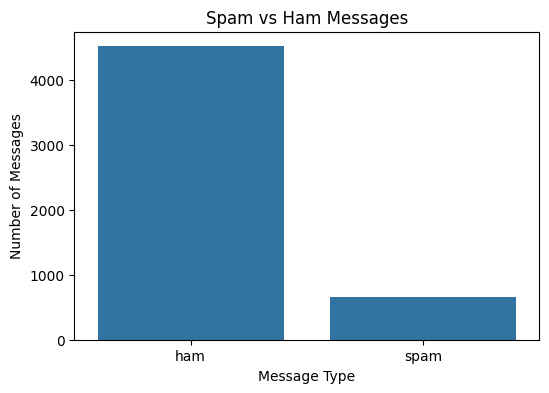

In [ ]:

df = df.drop_duplicates().reset_index(drop=True)
print("Dataset shape after removing duplicates:", df.shape)
print("\nMessage Distribution:")
print(df["label"].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

In [ ]:
percentage = df["label"].value_counts(normalize=True) * 100
print("Message Distribution (%)")
print(percentage.round(2))

Message Distribution (%)
label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)
df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [ ]:
print("Original message:")
print(df["message"].iloc[0])
print("\nCleaned message:")
print(df["clean_message"].iloc[0])
print("\nEmpty cleaned messages:",
      (df["clean_message"].str.strip() == "").sum())

Original message:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned message:
go jurong point crazy available bugis n great world la e buffet cine got amore wat

Empty cleaned messages: 6


In [ ]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1})
print(df[["label", "label_num"]].head())
print("\nLabel values:")
print(df["label_num"].value_counts())

  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0

Label values:
label_num
0    4516
1     653
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X = df["clean_message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 5000)
Testing TF-IDF shape: (1034, 5000)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report)
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Ham", "Spam"]
))

Naive Bayes Results
-------------------
Accuracy : 0.9652
Precision: 1.0
Recall   : 0.7252
F1 Score : 0.8407

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.73      0.84       131

    accuracy                           0.97      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.97      0.97      0.96      1034



In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42)
logistic_model.fit(X_train_tfidf, y_train)
y_pred_lr = logistic_model.predict(X_test_tfidf)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Ham", "Spam"]))

Logistic Regression Results
---------------------------
Accuracy : 0.9545
Precision: 0.9468
Recall   : 0.6794
F1 Score : 0.7911

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      0.99      0.97       903
        Spam       0.95      0.68      0.79       131

    accuracy                           0.95      1034
   macro avg       0.95      0.84      0.88      1034
weighted avg       0.95      0.95      0.95      1034



In [ ]:
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy],
    "Precision": [nb_precision, lr_precision],
    "Recall": [nb_recall, lr_recall],
    "F1 Score": [nb_f1, lr_f1]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.9652,1.0000,0.7252,0.8407
1,Logistic Regression,0.9545,0.9468,0.6794,0.7911


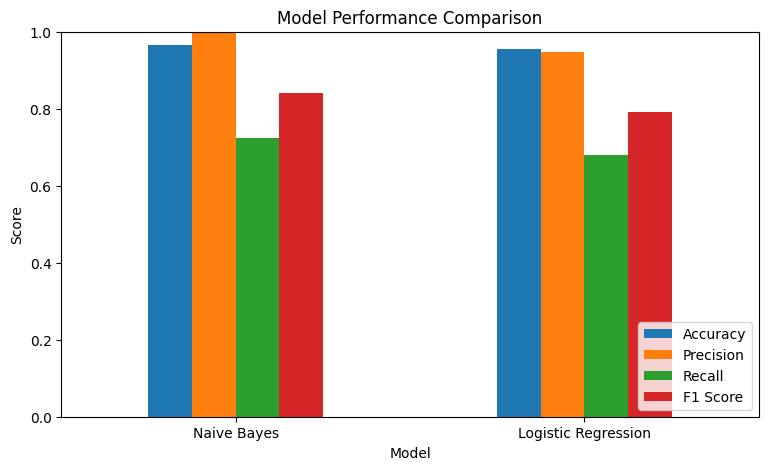

In [ ]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [ ]:
if lr_f1 >= nb_f1:
    best_model = logistic_model
    best_predictions = y_pred_lr
    best_model_name = "Logistic Regression"
else:
    best_model = nb_model
    best_predictions = y_pred_nb
    best_model_name = "Naive Bayes"
print("Selected Best Model:", best_model_name)

Selected Best Model: Naive Bayes


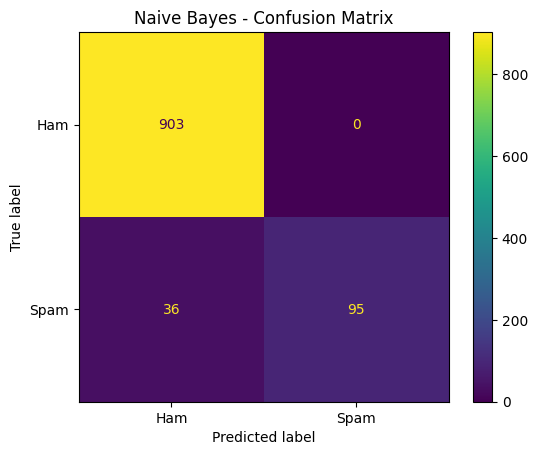

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, best_predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"])
disp.plot()
plt.title(f"{best_model_name} - Confusion Matrix")
plt.show()

In [ ]:
test_messages = [
    "Congratulations! You have won a free prize. Call now to claim.",
    "Hey, are you coming to college today?",
    "URGENT! You have won 1000 dollars. Click now!",
    "Can you send me the project file?",
    "You have been selected for a free vacation. Reply WIN now."]
for message in test_messages:
    cleaned = clean_text(message)
    message_tfidf = tfidf.transform([cleaned])
    prediction = best_model.predict(message_tfidf)[0]

    result = "Spam" if prediction == 1 else "Ham"

    print("Message:", message)
    print("Prediction:", result)
    print("-" * 60)

Message: Congratulations! You have won a free prize. Call now to claim.
Prediction: Spam
------------------------------------------------------------
Message: Hey, are you coming to college today?
Prediction: Ham
------------------------------------------------------------
Message: URGENT! You have won 1000 dollars. Click now!
Prediction: Ham
------------------------------------------------------------
Message: Can you send me the project file?
Prediction: Ham
------------------------------------------------------------
Message: You have been selected for a free vacation. Reply WIN now.
Prediction: Spam
------------------------------------------------------------


In [ ]:
def predict_sms(message):
    cleaned = clean_text(message)
    message_tfidf = tfidf.transform([cleaned])
    prediction = best_model.predict(message_tfidf)[0]

    return "Spam" if prediction == 1 else "Ham"
message = input("Enter an SMS message: ")
print("\nPredicted Class:", predict_sms(message))

Enter an SMS message: you got 1000000

Predicted Class: Ham


In [ ]:
print("=" * 50)
print("FINAL PROJECT RESULTS")
print("=" * 50)
print("\nNaive Bayes")
print("Accuracy :", round(nb_accuracy * 100, 2), "%")
print("F1 Score :", round(nb_f1, 4))
print("\nLogistic Regression")
print("Accuracy :", round(lr_accuracy * 100, 2), "%")
print("F1 Score :", round(lr_f1, 4))
print("\nBest Model:", best_model_name)
print("=" * 50)

FINAL PROJECT RESULTS

Naive Bayes
Accuracy : 96.52 %
F1 Score : 0.8407

Logistic Regression
Accuracy : 95.45 %
F1 Score : 0.7911

Best Model: Naive Bayes


In [ ]:
import joblib
joblib.dump(best_model, "sms_spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!
